Loading data from Kaggle

In [ ]:
# Load directly from Kaggle input directory

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "amazon.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "karkavelrajaj/amazon-sales-dataset",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_1076/858415233.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 1.95M/1.95M [00:00<00:00, 89.9MB/s]

Extracting zip of amazon.csv...


First 5 records:    product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349     

Exploring the dataset


In [ ]:

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nSample ratings:", df['rating'].unique()[:10])

Shape: (1465, 16)

Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

Data types:
 product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

Missing values:
 product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
ab

Preprocessing the Dataset

In [ ]:

import re
import pandas as pd

df_clean = df.copy()

# Remove ₹ and commas from price columns, convert to float
df_clean['discounted_price'] = df_clean['discounted_price'].str.replace('[₹,]', '', regex=True).astype(float)
df_clean['actual_price']     = df_clean['actual_price'].str.replace('[₹,]', '', regex=True).astype(float)
df_clean['discount_percentage'] = df_clean['discount_percentage'].str.replace('%', '', regex=False).astype(float)

# Remove commas from rating count, convert to float
df_clean['rating_count'] = df_clean['rating_count'].str.replace(',', '', regex=False)
df_clean['rating_count'] = pd.to_numeric(df_clean['rating_count'], errors='coerce')

# Convert rating to float
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')


df_clean['main_category'] = df_clean['category'].str.split('|').str[0]

# Fill missing text fields
df_clean['review_content'] = df_clean['review_content'].fillna('')
df_clean['about_product']  = df_clean['about_product'].fillna('')

# Drop rows with missing critical values
df_clean = df_clean.dropna(subset=['product_name', 'rating', 'discounted_price'])

df_clean = df_clean.reset_index(drop=True)

print("Cleaned shape:", df_clean.shape)
df_clean.head(3)

Cleaned shape: (1464, 17)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories


In [ ]:
# Descriptive Statistics
print(df_clean[['rating','discounted_price','actual_price','discount_percentage','rating_count']].describe())

            rating  discounted_price   actual_price  discount_percentage  \
count  1464.000000       1464.000000    1464.000000          1464.000000   
mean      4.096585       3126.011906    5447.002923            47.713115   
std       0.291674       6946.625442   10878.270001            21.627422   
min       2.000000         39.000000      39.000000             0.000000   
25%       4.000000        323.750000     800.000000            32.000000   
50%       4.100000        799.000000    1650.000000            50.000000   
75%       4.300000       1999.000000    4303.750000            63.000000   
max       5.000000      77990.000000  139900.000000            94.000000   

        rating_count  
count    1462.000000  
mean    18307.376881  
std     42766.096572  
min         2.000000  
25%      1191.500000  
50%      5179.000000  
75%     17342.250000  
max    426973.000000  


Exploratory Data Analysis

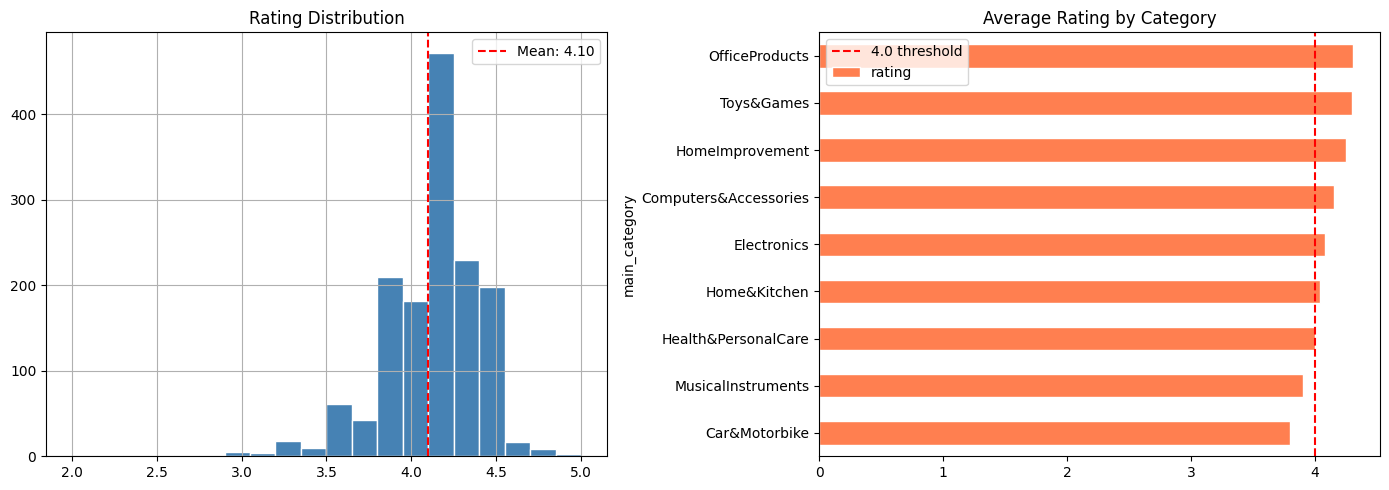

In [ ]:
import matplotlib.pyplot as plt

# 1. Rating Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
df_clean['rating'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df_clean['rating'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['rating'].mean():.2f}")
axes[0].set_title('Rating Distribution')
axes[0].legend()

# Average rating per category
df_clean.groupby('main_category')['rating'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Rating by Category')
axes[1].axvline(4.0, color='red', linestyle='--', label='4.0 threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

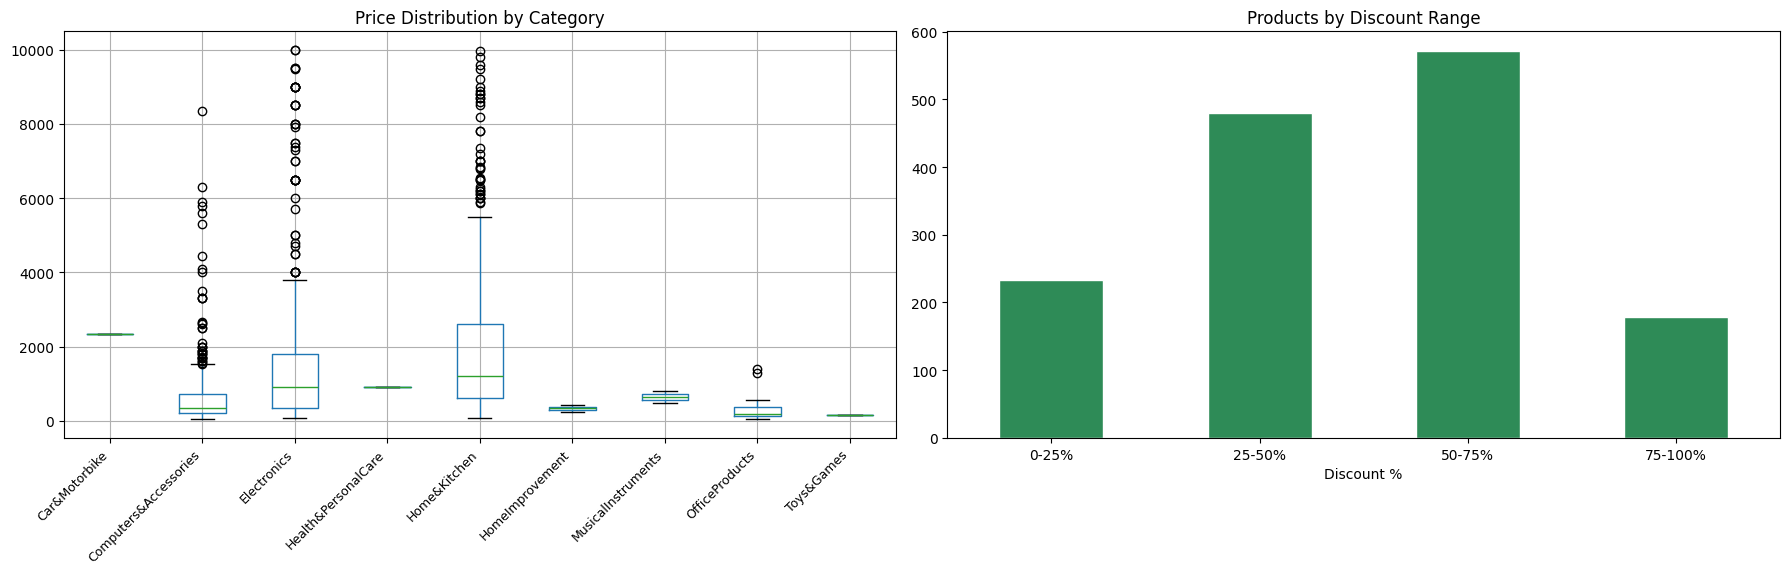

In [ ]:
#2. Price Analysis
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Price by category (boxplot)
df_clean[df_clean['discounted_price'] < 10000].boxplot(
    column='discounted_price', by='main_category', ax=axes[0])
axes[0].set_title('Price Distribution by Category')
axes[0].set_xlabel('')

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

# discount buckets
bins = [0, 25, 50, 75, 100]
labels = ['0-25%', '25-50%', '50-75%', '75-100%']
df_clean['discount_bucket'] = pd.cut(
    df_clean['discount_percentage'], bins=bins, labels=labels, right=False
)

# Discount bucket distribution
discount_counts = df_clean['discount_bucket'].value_counts().sort_index()
discount_counts.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Products by Discount Range')
axes[1].set_xlabel('Discount %')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.show()

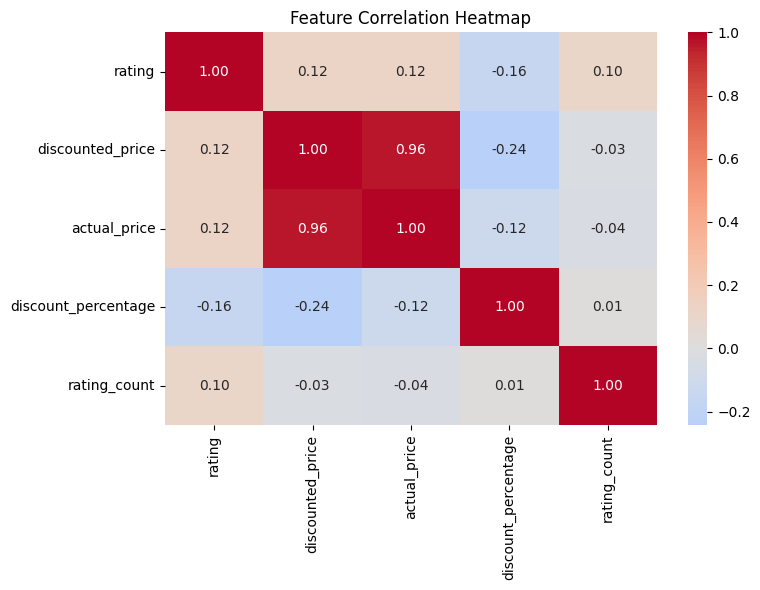

In [ ]:
# 3. Correlation Heatmap
import seaborn as sns

corr = df_clean[['rating', 'discounted_price', 'actual_price',
                  'discount_percentage', 'rating_count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

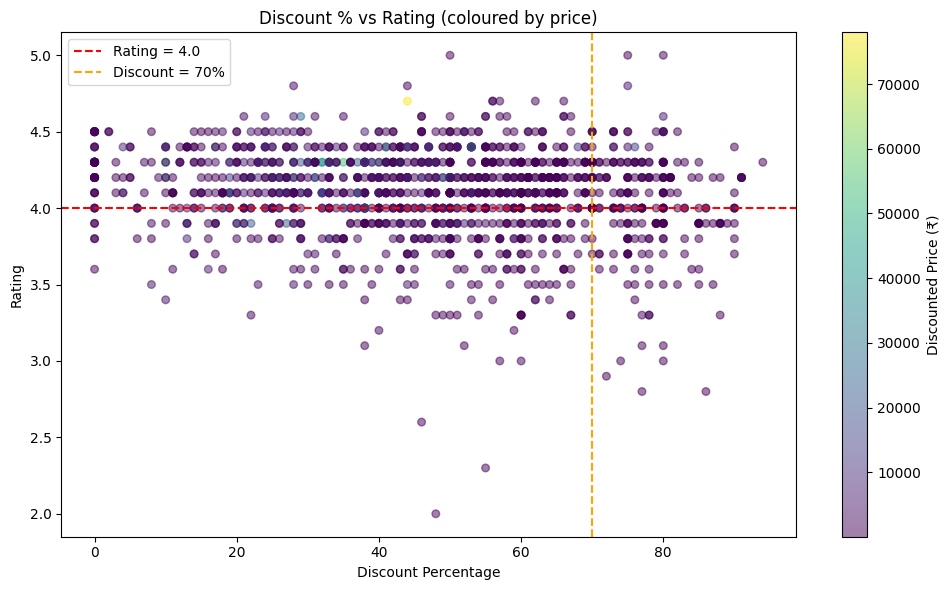

Products with >70% discount AND rating ≥ 4.0: 137


In [ ]:
# 4. Do Heavily Discounted Products Have Good Ratings?
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_clean['discount_percentage'],
                     df_clean['rating'],
                     c=df_clean['discounted_price'],
                     cmap='viridis', alpha=0.5, s=30)

plt.colorbar(scatter, label='Discounted Price (₹)')
ax.axhline(4.0, color='red', linestyle='--', label='Rating = 4.0')
ax.axvline(70, color='orange', linestyle='--', label='Discount = 70%')
ax.set_xlabel('Discount Percentage')
ax.set_ylabel('Rating')
ax.set_title('Discount % vs Rating (coloured by price)')
ax.legend()
plt.tight_layout()
plt.show()

high_both = df_clean[(df_clean['discount_percentage'] > 70) & (df_clean['rating'] >= 4.0)]
print(f"Products with >70% discount AND rating ≥ 4.0: {len(high_both)}")

Importing all required libraries for NLP, vector search, recommendation scoring, and LLM generation here.

In [ ]:

# IMPORTS
!pip install vaderSentiment sentence-transformers faiss-cpu transformers networkx -q

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer
from transformers import pipeline as hf_pipeline
import faiss



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 41.3 MB/s eta 0:00:00


Combined Text Creation — merging product fields for embedding

In [ ]:

# COMBINED TEXT
def clean_text_for_embedding(text):
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df_clean['combined_text'] = (
    df_clean['product_name'].apply(
        clean_text_for_embedding) + " " +
    df_clean['main_category'].apply(
        clean_text_for_embedding) + " " +
    df_clean['about_product'].apply(
        clean_text_for_embedding) + " " +
    df_clean['review_title'].apply(
        clean_text_for_embedding) + " " +
    df_clean['review_content'].apply(
        clean_text_for_embedding)
)

print(f"Sample: {df_clean['combined_text'].iloc[0][:200]}")

Sample: wayona nylon braided usb to lightning fast charging and data sync cable compatible for iphone 13 12 11 x 8 7 6 5 ipad air pro mini 3 ft pack of 1 grey computers accessories high compatibility compatib


Knowledge Representation — category hierarchy extraction

In [ ]:

# KNOWLEDGE REPRESENTATION (Category Structure)

# Extract category levels
df_clean['main_category'] = df_clean['category']\
    .apply(lambda x: str(x).split('|')[0].strip())
df_clean['sub_category'] = df_clean['category']\
    .apply(lambda x: str(x).split('|')[1].strip()
           if len(str(x).split('|')) > 1 else 'General')

# Show the category structure
print("=== Category Hierarchy (Knowledge Structure) ===")
print(f"Main Categories: {df_clean['main_category'].nunique()}")
print(f"Sub Categories:  {df_clean['sub_category'].nunique()}")
print("\nTop 10 Main Categories:")
print(df_clean['main_category'].value_counts().head(10))

# Category-based retrieval function
def get_products_by_category(category, n=5):
    filtered = df_clean[
        df_clean['category'].str.contains(
            category, case=False, na=False)]
    if filtered.empty:
        return f"No products found for: {category}"
    return filtered.nlargest(n, 'rating')[
        ['product_name', 'main_category',
         'rating', 'discounted_price']]


print("\n=== Category Retrieval Test ===")
top_cat = df_clean['main_category'].value_counts().index[0]
print(f"Top products in '{top_cat}':")
print(get_products_by_category(top_cat, n=3)\
      .to_string(index=False))

=== Category Hierarchy (Knowledge Structure) ===
Main Categories: 9
Sub Categories:  29

Top 10 Main Categories:
main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

=== Category Retrieval Test ===
Top products in 'Electronics':
                                                                                                                                                                                            product_name main_category  rating  discounted_price
                                                                                                                        Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black)   Electronics     4.7           77990.0
                                        

Sentiment Analysis (NLP) — VADER-based review scoring

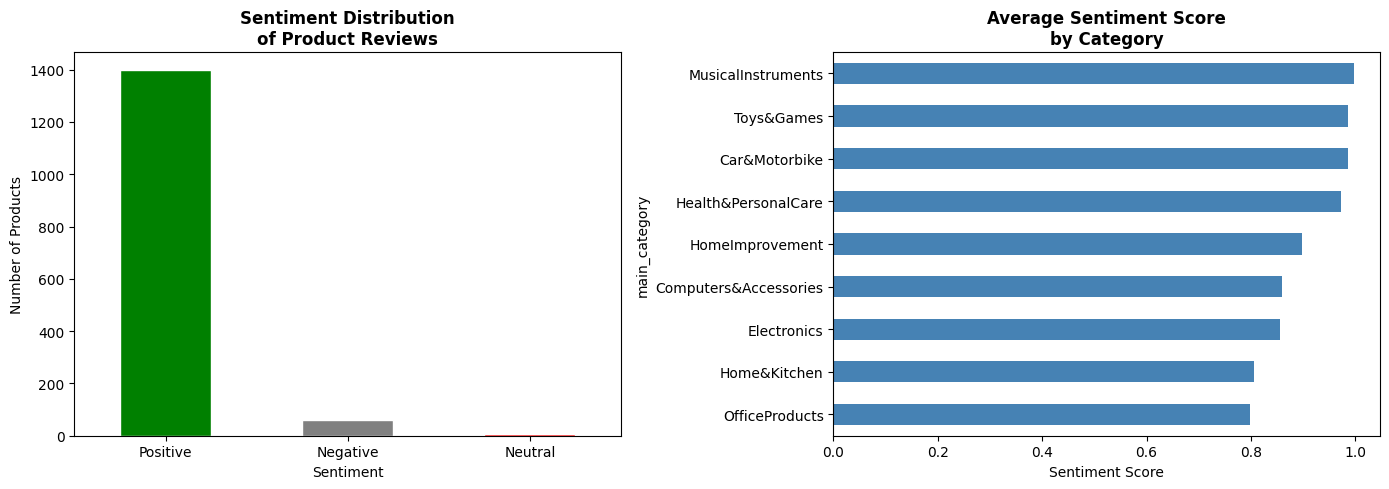

In [ ]:

# SENTIMENT ANALYSIS (NLP Paradigm)

analyzer = SentimentIntensityAnalyzer()

df_clean['sentiment_score'] = df_clean['review_content']\
    .apply(lambda text:
           analyzer.polarity_scores(str(text))['compound'])

def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_clean['sentiment_label'] = df_clean['sentiment_score']\
    .apply(sentiment_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df_clean['sentiment_label'].value_counts()\
    .plot(kind='bar', ax=axes[0],
          color=['green','gray','red'],
          edgecolor='white')
axes[0].set_title('Sentiment Distribution\nof Product Reviews',
                  fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Products')
axes[0].tick_params(axis='x', rotation=0)

# Average sentiment by category
df_clean.groupby('main_category')['sentiment_score']\
    .mean().sort_values()\
    .plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Average Sentiment Score\nby Category',
                  fontweight='bold')
axes[1].set_xlabel('Sentiment Score')

plt.tight_layout()
plt.show()



TF-IDF Vectorisation- content-based similarity

In [ ]:

# TF-IDF VECTORIZER (Content-Based)

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000)

tfidf_matrix = tfidf.fit_transform(
    df_clean['combined_text'])

print(f" TF-IDF matrix shape: {tfidf_matrix.shape}")

 TF-IDF matrix shape: (1464, 5000)


Feature Normalisation — scaling all signals to 0–1

In [ ]:

# NORMALISE FEATURES

scaler = MinMaxScaler()
df_clean['rating_norm']     = scaler.fit_transform(df_clean[['rating']])
df_clean['discount_norm']   = scaler.fit_transform(df_clean[['discount_percentage']])
df_clean['popularity_norm'] = scaler.fit_transform(df_clean[['rating_count']].fillna(0))
df_clean['sentiment_norm']  = (df_clean['sentiment_score'] + 1) / 2


Logic-Based Filtering

In [ ]:

# LOGIC-BASED RULE FILTER (Logic Paradigm)

def apply_filters(data, max_price=None, min_rating=None, category=None):
    filtered = data.copy()
    if max_price is not None:
        filtered = filtered[filtered['discounted_price'] <= max_price]
    if min_rating is not None:
        filtered = filtered[filtered['rating'] >= min_rating]
    if category is not None:
        filtered = filtered[
            filtered['main_category'].str.lower() == category.lower()]
    return filtered


 Hybrid Recommendation- Combines TF-IDF similarity + sentiment + rating + popularity + discount

In [ ]:

# STEP 8 — HYBRID RECOMMENDATION FUNCTION

def hybrid_recommend(query, max_price=None, min_rating=None,
                     category=None, top_n=5):


    if not query or not query.strip():
        return "Please enter a valid search query."

    #Apply logic filters
    filtered = apply_filters(df_clean, max_price, min_rating, category)
    if filtered.empty:
        return "No products found matching your filters."

    #TF-IDF similarity between query and products
    query_vec = tfidf.transform([query])
    sim_scores = cosine_similarity(
        query_vec, tfidf_matrix[filtered.index]).flatten()

    filtered = filtered.copy()
    filtered['similarity'] = sim_scores

    # Weighted hybrid score
    filtered['final_score'] = (
        0.35 * filtered['similarity']      +  # query relevance
        0.25 * filtered['sentiment_norm']  +  # customer sentiment
        0.20 * filtered['rating_norm']     +  # star rating
        0.10 * filtered['popularity_norm'] +  # number of reviews
        0.10 * filtered['discount_norm']      # discount
    )

    # top N products
    top = filtered.sort_values('final_score', ascending=False).head(top_n)
    return top[['product_name', 'main_category', 'discounted_price',
                'rating', 'sentiment_label', 'final_score','sentiment_score']]


print("=== Hybrid Recommendation Test ===")
result = hybrid_recommend("fast charging cable", max_price=500, min_rating=4.0)
print(result.to_string(index=False))


=== Hybrid Recommendation Test ===
                                                                                                                                                                                                  product_name         main_category  discounted_price  rating sentiment_label  final_score  sentiment_score
                                            Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed, Fast Charging Multi Purpose Cable 1.25 Mtr Long, Type C cable, Micro Usb Cable and Cable for iPhone, White Computers&Accessories             348.0     4.2        Positive     0.704253           0.9088
                                            Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed, Fast Charging Multi Purpose Cable 1.25 Mtr Long, Type C cable, Micro Usb Cable and Cable for iPhone, White Computers&Accessories             348.0     4.2        Positive     0.704253           0.9088
Lapster 65W compatible for OnePlus Dash Warp Charge Cable , ty

Human readable recommendation which wraps the hybrid_recommend() results

In [ ]:
def show_with_explanation(query,
                          max_price=None,
                          min_rating=None,
                          top_n=5):
    result = hybrid_recommend(
        query, max_price, min_rating, top_n=top_n)

    if not isinstance(result, pd.DataFrame):
        print(result)
        return

    print(f"\n Query: '{query}'")
    print("=" * 60)
    for _, row in result.iterrows():

        sentiment_text = (
            "highly praised by customers"
            if row['sentiment_label'] == 'Positive'
            else "has mixed or negative reviews")

        print(f"\n {row['product_name'][:60]}")
        print(f"    Rating    : {row['rating']}")
        print(f"    Price     : ₹{row['discounted_price']}")
        print(f"    Sentiment : {row['sentiment_label']}")
        print(f"    Why: Matches your query "
              f"and is {sentiment_text}.")
        print(f"    Score     : {row['final_score']:.4f}")
        print("-" * 60)


show_with_explanation(
    "fast charging cable",
    max_price=500,
    min_rating=4.0)


 Query: 'fast charging cable'

 Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed, Fast
    Rating    : 4.2
    Price     : ₹348.0
    Sentiment : Positive
    Why: Matches your query and is highly praised by customers.
    Score     : 0.7043
------------------------------------------------------------

 Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed, Fast
    Rating    : 4.2
    Price     : ₹348.0
    Sentiment : Positive
    Why: Matches your query and is highly praised by customers.
    Score     : 0.7043
------------------------------------------------------------

 Lapster 65W compatible for OnePlus Dash Warp Charge Cable , 
    Rating    : 4.5
    Price     : ₹199.0
    Sentiment : Positive
    Why: Matches your query and is highly praised by customers.
    Score     : 0.6609
------------------------------------------------------------

 Lapster 65W compatible for OnePlus Dash Warp Charge Cable , 
    Rating    : 4.5
    Price     : ₹199.0
    Sentiment : Positive
 

RAG + LLM Model (Generative AI)

In [ ]:

#RAG + LLM

# semantic embeddings for all products
print("Generating embeddings (this may take a minute)...")
embedder   = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(df_clean['combined_text'].tolist(),
                             show_progress_bar=True,
                             batch_size=32)
embeddings = np.array(embeddings, dtype='float32')

#Storing embeddings in FAISS for fast search
faiss_index = faiss.IndexFlatL2(embeddings.shape[1])
faiss_index.add(embeddings)
print(f"FAISS index ready: {faiss_index.ntotal} products")

#Loading a small LLM for text generation
print("Loading LLM...")
llm = hf_pipeline("text-generation",
                  model="facebook/opt-125m",
                  max_new_tokens=120,
                  do_sample=True,
                  temperature=0.7)
print(" LLM ready")


def rag_recommend(query, k=5):

    # Input check
    if not query or not query.strip():
        return None, "Please enter a valid query."

    # Embedding the user query
    query_emb = np.array(embedder.encode([query]), dtype='float32')

    # Finding k most similar products via FAISS
    _, indices = faiss_index.search(query_emb, k)
    products   = df_clean.iloc[indices[0]][
        ['product_name', 'main_category', 'rating',
         'discounted_price', 'sentiment_label']]

    # Building context string from retrieved products
    context = "\n".join([
        f"- {r['product_name']} | Rating: {r['rating']} "
        f"| Price: ₹{r['discounted_price']} | {r['sentiment_label']}"
        for _, r in products.iterrows()
    ])

    # LLM generates a response using the context
    prompt = (f"You are a shopping assistant.\n"
              f"User wants: {query}\n\n"
              f"Available products:\n{context}\n\n"
              f"Recommend the best option:")
    response = llm(prompt)[0]['generated_text']
    response = response.replace(prompt, '').strip()

    return products, response


# test
print("\n=== RAG + LLM Test ===")
products, response = rag_recommend("good cable for iPhone")
print("\nRetrieved Products:")
print(products[['product_name', 'rating', 'discounted_price']].to_string(index=False))
print(f"\nAI Response:\n{response}")

Generating embeddings (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 LLM ready

=== RAG + LLM Test ===

Retrieved Products:
                                                                                                                                                                                           product_name  rating  discounted_price
                                             Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black     4.5             970.0
                                             Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black     4.5             970.0
                                             Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black     4.5             970.0
                                        

Baseline model on the basis of rating

In [ ]:

#BASELINE MODEL (For Comparison)

def baseline(top_n=5):
    return df_clean.sort_values('rating', ascending=False).head(top_n)[
        ['product_name', 'rating', 'main_category']]

print("=== Baseline (Rating Only) ===")
print(baseline().to_string(index=False))

=== Baseline (Rating Only) ===
                                                                                                                                                                                                                                                                product_name  rating         main_category
                                                                                             Syncwire LTG to USB Cable for Fast Charging Compatible with Phone 5/ 5C/ 5S/ 6/ 6S/ 7/8/ X/XR/XS Max/ 11/12/ 13 Series and Pad Air/Mini, Pod & Other Devices (1.1 Meter, White)     5.0 Computers&Accessories
                                                                               REDTECH USB-C to Lightning Cable 3.3FT, [Apple MFi Certified] Lightning to Type C Fast Charging Cord Compatible with iPhone 14/13/13 pro/Max/12/11/X/XS/XR/8, Supports Power Delivery - White     5.0 Computers&Accessories
                                                                        

Evaluation using metrics

Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Total relevant products (rating ≥ 4.0): 1110

MODEL EVALUATION RESULTS
    Model  Precision@5  Recall@5  NDCG@5  Time (s)
 Baseline          1.0    0.0045  1.0000    0.0024
Hybrid AI          1.0    0.0045  1.0000    0.0173
RAG + LLM          0.6    0.0027  0.4469   14.2654


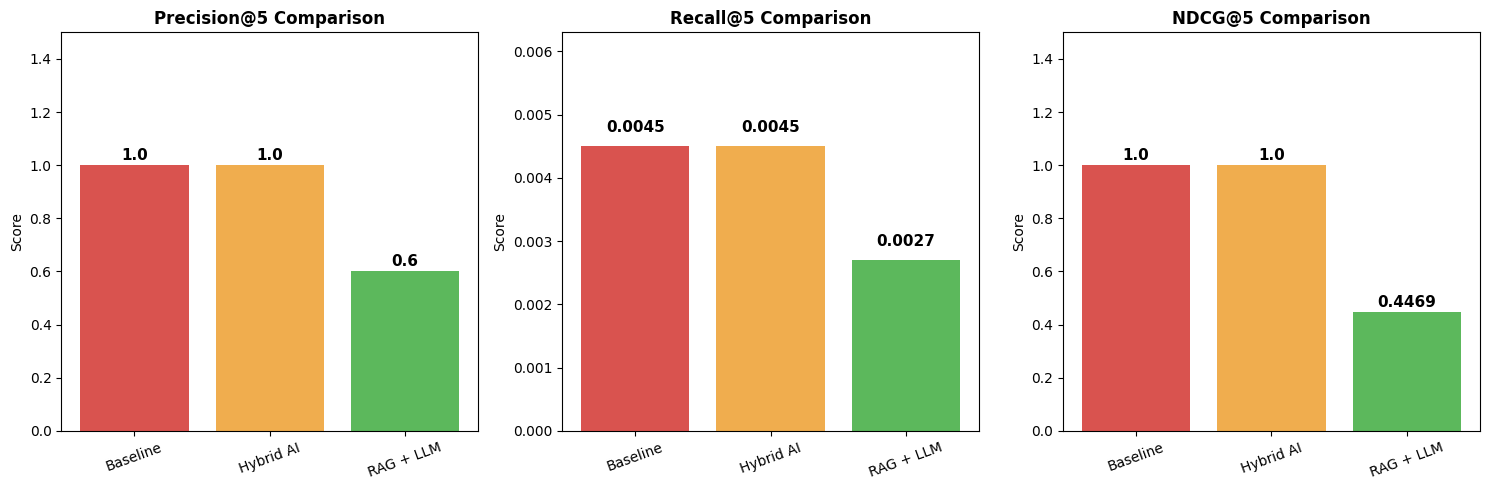

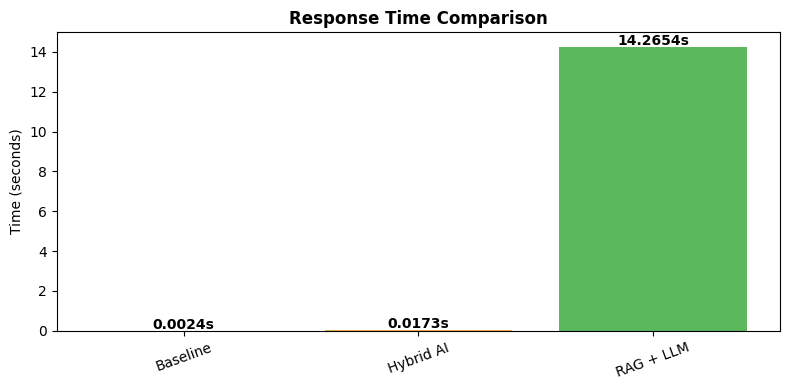

In [ ]:

#Evaluation (Precision, Recall, NDCG)

def precision_at_k(recommended, relevant, k=5):
    hits = len(set(list(recommended)[:k]) & set(relevant))
    return round(hits / k, 4)

def recall_at_k(recommended, relevant, k=5):
    hits = len(set(list(recommended)[:k]) & set(relevant))
    return round(hits / len(relevant), 4) if relevant else 0

def ndcg_at_k(recommended, relevant, k=5):
    dcg  = sum([1/np.log2(i+2) for i, r in
                enumerate(list(recommended)[:k])
                if r in relevant])
    idcg = sum([1/np.log2(i+2)
                for i in range(min(len(relevant), k))])
    return round(dcg / idcg, 4) if idcg > 0 else 0

#all products with rating >= 4.0
relevant = set(
    df_clean[df_clean['rating'] >= 4.0].index.tolist())
print(f"Total relevant products (rating ≥ 4.0): {len(relevant)}")

test_query = "fast charging cable"

# Baseline model
t0 = time.time()
baseline_results = df_clean.sort_values(
    'rating', ascending=False).head(5)
rec_baseline = baseline_results.index.tolist()
t_baseline = round(time.time() - t0, 4)

# Hybrid model
t0 = time.time()
hybrid_results = hybrid_recommend(test_query, top_n=5)
rec_hybrid = hybrid_results.index.tolist() \
    if isinstance(hybrid_results, pd.DataFrame) else []
t_hybrid = round(time.time() - t0, 4)

# RAG + LLM model
t0 = time.time()
rag_products, _ = rag_recommend(test_query, k=5)
rec_rag = rag_products.index.tolist() \
    if isinstance(rag_products, pd.DataFrame) else []
t_rag = round(time.time() - t0, 4)

# Results table
eval_df = pd.DataFrame({
    'Model'      : ['Baseline', 'Hybrid AI', 'RAG + LLM'],
    'Precision@5': [precision_at_k(rec_baseline, relevant),
                    precision_at_k(rec_hybrid,   relevant),
                    precision_at_k(rec_rag,       relevant)],
    'Recall@5'   : [recall_at_k(rec_baseline, relevant),
                    recall_at_k(rec_hybrid,   relevant),
                    recall_at_k(rec_rag,       relevant)],
    'NDCG@5'     : [ndcg_at_k(rec_baseline, relevant),
                    ndcg_at_k(rec_hybrid,   relevant),
                    ndcg_at_k(rec_rag,       relevant)],
    'Time (s)'   : [t_baseline, t_hybrid, t_rag]
})

print("\n" + "=" * 55)
print("MODEL EVALUATION RESULTS")
print("=" * 55)
print(eval_df.to_string(index=False))

# graph
colours = ['#d9534f', '#f0ad4e', '#5cb85c']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes,
                      ['Precision@5', 'Recall@5', 'NDCG@5']):
    bars = ax.bar(eval_df['Model'],
                  eval_df[metric], color=colours)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel('Score')


    if metric == 'Recall@5':
        max_val = eval_df[metric].max()
        ax.set_ylim(0, max_val * 1.4)
    else:
        ax.set_ylim(0, 1.5)
    ax.tick_params(axis='x', rotation=20)


    for bar, val in zip(bars, eval_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max_val * 0.05
                if metric == 'Recall@5' else 0.02),
                str(val), ha='center',
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Response time chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(eval_df['Model'],
              eval_df['Time (s)'], color=colours)
ax.set_title('Response Time Comparison', fontweight='bold')
ax.set_ylabel('Time (seconds)')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, eval_df['Time (s)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{val}s", ha='center',
            fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()


System Testing

In [ ]:

# SYSTEM TESTING

print("\n" + "=" * 55)
print("SYSTEM TESTING")
print("=" * 55)


print("\n TEST 1 — Basic Queries")
for q in ["charging cable", "wireless headphones", "laptop"]:
    res = hybrid_recommend(q, top_n=3)
    ok  = isinstance(res, pd.DataFrame) and len(res) > 0
    print(f"  {'Y' if ok else 'N'} '{q}' → "
          f"{res.iloc[0]['product_name'][:45] if ok else res}...")


print("\n TEST 2 — Filter Validation")
res = hybrid_recommend("cable", max_price=300, top_n=5)
if isinstance(res, pd.DataFrame):
    ok = res['discounted_price'].max() <= 300
    print(f"  {'Y' if ok else 'N'} Price filter "
          f"(max ₹300): highest = ₹{res['discounted_price'].max()}")

res = hybrid_recommend("cable", min_rating=4.0, top_n=5)
if isinstance(res, pd.DataFrame):
    ok = res['rating'].min() >= 4.0
    print(f"  {'Y' if ok else 'N'} Rating filter "
          f"(≥4.0): lowest = {res['rating'].min()}")


print("\n TEST 3 — Edge Cases")
res = hybrid_recommend("")
print(f"  Empty query handled: '{res}'")

res = hybrid_recommend("cable", max_price=1, min_rating=5.0)
print(f"  Impossible filter handled: '{res}'")


print("\n TEST 4 — RAG + LLM")
for q in ["best cable for iPhone", "budget laptop"]:
    prods, resp = rag_recommend(q)
    print(f"  '{q}' → {len(prods)} products retrieved")
    print(f"     AI: {resp[:80]}...")



Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



SYSTEM TESTING

 TEST 1 — Basic Queries
  Y 'charging cable' → Wecool Unbreakable 3 in 1 Charging Cable with...
  Y 'wireless headphones' → Amazon Basics High-Speed HDMI Cable, 6 Feet (...
  Y 'laptop' → Dyazo 6 Angles Adjustable Aluminum Ergonomic ...

 TEST 2 — Filter Validation
  Y Price filter (max ₹300): highest = ₹219.0
  Y Rating filter (≥4.0): lowest = 4.2

 TEST 3 — Edge Cases
  Empty query handled: 'Please enter a valid search query.'
  Impossible filter handled: 'No products found matching your filters.'

 TEST 4 — RAG + LLM


Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  'best cable for iPhone' → 5 products retrieved
     AI: - USB Type-C (USB Type-A)
- 2.5mm headphone jack
- 2.5mm headphone jack
- 2.5mm ...
  'budget laptop' → 5 products retrieved
     AI: - Lenovo IdeaPad 3 11th Gen Intel Core i3 15.6"FHD Thin & Light Laptop | Rating:...


In [ ]:
#saving results

eval_df.to_csv("evaluation_results.csv", index=False)

In [ ]:
# Run 5 different queries and check if responses make sense
test_queries = [
    "best laptop for students",
    "fast charging cable under 500",
    "wireless headphones with good bass",
    "budget smartphone",
    "gaming mouse"
]

print("=== RAG RESPONSE QUALITY TEST ===\n")
for query in test_queries:
    products, response = rag_recommend(query)
    print(f"Query: '{query}'")
    print(f"Top product: {products.iloc[0]['product_name'][:60]}")
    print(f"AI Response: {response[:150]}")
    print("-" * 50)

Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== RAG RESPONSE QUALITY TEST ===



Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: 'best laptop for students'
Top product: Lenovo IdeaPad 3 11th Gen Intel Core i3 15.6" FHD Thin & Lig
AI Response: Best option: Dell Q70-E7KG-SQ1
Recommend the best option:
- Dell Q70-E9KG-SQ5
Recommend the best option:
- Dell Q70-E9KG-SQ9

Recommend the best optio
--------------------------------------------------


Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: 'fast charging cable under 500'
Top product: boAt Type C A750 Stress Resistant, Tangle-free, Sturdy Flat 
AI Response: Free WiFi for your home

FREE WiFi for your home.

The best option:

Free WiFi for your home.

Our Wi-Fi works at all your devices.

Free WiFi for you
--------------------------------------------------


Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: 'wireless headphones with good bass'
Top product: boAt Bassheads 225 in Ear Wired Earphones with Mic(Blue)
AI Response: boAt Bassheads 225 in Ear Wired Earphones with Mic(Blue) | Rating: 4.2 | Price: ₹699.0 | Positive

Available products: boAt Bassheads 225 in Ear Wired
--------------------------------------------------


Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: 'budget smartphone'
Top product: Redmi Note 11 (Horizon Blue, 6GB RAM, 64GB Storage)|90Hz FHD
AI Response: - Samsung Galaxy M33 5G (Mystique Green, 8GB, 128GB Storage) | 6000mAh Battery | Upto 16GB RAM with RAM Plus | Travel Adapter to be Purchased Separate
--------------------------------------------------
Query: 'gaming mouse'
Top product: Ant Esports GM320 RGB Optical Wired Gaming Mouse | 8 Program
AI Response: Buy a Razer Blackadder Pro Pro Gaming Mouse. The mouse’s ergonomics are very good.

Best Mouse: Razer Blackadder Pro Gaming Mouse | Redstone Gaming Mo
--------------------------------------------------


Cold Start Test — queries with no exact dataset match

In [ ]:
print("COLD START TEST\n")

cold_queries = [
    "xyzabc123",
    "gaming laptop RTX",
    "iPhone 15 case"
]

for query in cold_queries:
    result = hybrid_recommend(query, top_n=3)
    if isinstance(result, pd.DataFrame):
        print(f"Query: '{query}'")
        print(f"Results returned: {len(result)}")
        print(f"Top: {result.iloc[0]['product_name'][:50]}")
        print(f"Final score: {result.iloc[0]['final_score']:.4f}")
    else:
        print(f"Query: '{query}' → {result}")
    print("-" * 40)

COLD START TEST

Query: 'xyzabc123'
Results returned: 3
Top: Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pac
Final score: 0.5923
----------------------------------------
Query: 'gaming laptop RTX'
Results returned: 3
Top: Dyazo 6 Angles Adjustable Aluminum Ergonomic Folda
Final score: 0.6361
----------------------------------------
Query: 'iPhone 15 case'
Results returned: 3
Top: Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pac
Final score: 0.5923
----------------------------------------


Diversity Test— checks if recommendations vary across categories or repeat same products

In [ ]:
# Check if recommendations are repetitive
print("=== DIVERSITY TEST ===\n")

result = hybrid_recommend("cable", top_n=10)
if isinstance(result, pd.DataFrame):
    categories = result['main_category'].unique()
    print(f"Top 10 recommendations for 'cable':")
    print(result[['product_name','main_category','rating']]\
          .to_string(index=False))
    print(f"\nUnique categories: {len(categories)}")
    print(f"Categories: {list(categories)}")

    if len(categories) == 1:
        print("\n All from same category — low diversity!")
    else:
        print("\n Good diversity across categories")

=== DIVERSITY TEST ===

Top 10 recommendations for 'cable':
                                                                                                                                                                                                  product_name         main_category  rating
                                                                                                                                                    Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black           Electronics     4.4
                                                                                                                                               Lapster usb 2.0 mantra cable, mantra mfs 100 data cable (black) Computers&Accessories     4.2
                                                                                                                                     AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot           Electronics 

LLM Consistency — same query run 3 times to check if LLM gives stable responses

In [ ]:
# Run same query 3 times — does LLM give different answers?
print("=== LLM CONSISTENCY TEST ===\n")

query = "best cable for fast charging"
for i in range(3):
    _, response = rag_recommend(query)
    print(f"Run {i+1}: {response[:120]}")
    print()

Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== LLM CONSISTENCY TEST ===



Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Run 1: - Best cable for fast charging for all type-c

- Best cable for fast charging for all type-c

- Best cable for fast char



Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Run 2: - USB Type C Cable | Charging Type - USB Type Cable | Charging Type - USB Type Cable | Charging Type - USB Type Cable | 

Run 3: - Tangle Resistant USB Type-C to 5-Pin USB Mobile Charging Cable    1.5 Meter (RCT15, Blue) Supports QC 2.0/3.0 Charging



Coverage Test — measures what % of the 1,465 products ever appear in recommendations

In [ ]:
# Check how many unique products appear in recommendations
print("=== DATASET COVERAGE TEST ===\n")

queries = ["cable", "laptop", "headphones",
           "charger", "phone", "keyboard"]

all_recommended = []
for q in queries:
    res = hybrid_recommend(q, top_n=5)
    if isinstance(res, pd.DataFrame):
        all_recommended.extend(res['product_name'].tolist())

unique_recommended = len(set(all_recommended))
total_products = len(df_clean)

print(f"Total products in dataset: {total_products}")
print(f"Unique products recommended: {unique_recommended}")
print(f"Coverage: {unique_recommended/total_products*100:.1f}%")

if unique_recommended < 20:
    print(" Low diversity — same products keep appearing")
else:
    print(" Good coverage across dataset")

=== DATASET COVERAGE TEST ===

Total products in dataset: 1464
Unique products recommended: 20
Coverage: 1.4%
 Good coverage across dataset


FULL SYSTEM DEMO

In [ ]:

# DEMO —Enter your query and get all results together

query      = "charging cable"
max_price  = 500
min_rating = 4.0
top_n      = 5

print("=" * 60)
print(f" QUERY: '{query}'")
if max_price:  print(f"   Max Price  : ₹{max_price}")
if min_rating: print(f"   Min Rating : {min_rating}")
print("=" * 60)

# Hybrid Recommendations
print("\n HYBRID AI RECOMMENDATIONS")
print("-" * 60)
hybrid_result = hybrid_recommend(
    query, max_price=max_price,
    min_rating=min_rating, top_n=top_n)

if isinstance(hybrid_result, pd.DataFrame):
    for i, (_, row) in enumerate(hybrid_result.iterrows(), 1):
        print(f"{i}. {row['product_name'][:55]}")
        print(f"   Rating {row['rating']} | "
              f"Price ₹{row['discounted_price']} | "
              f"Review {row['sentiment_label']} | "
              f"Final Score: {row['final_score']:.3f}")
else:
    print(hybrid_result)

# RAG + LLM Response
print("\n RAG + LLM RESPONSE")
print("-" * 60)
rag_products, rag_response = rag_recommend(query, k=top_n)

print("Retrieved Products:")
for i, (_, row) in enumerate(rag_products.iterrows(), 1):
    print(f"{i}. {row['product_name'][:55]}")
    print(f"   Rating {row['rating']} | "
          f"Money {row['discounted_price']} | "
          f"Review {row['sentiment_label']}")

print(f"\nAI Response:\n{rag_response}")

# Category Knowledge Filter
print("\n CATEGORY-BASED RESULTS")
print("-" * 60)
cat_result = get_products_by_category(query, n=3)
if isinstance(cat_result, pd.DataFrame):
    print(cat_result.to_string(index=False))
else:
    print(cat_result)

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
if isinstance(hybrid_result, pd.DataFrame):
    print(f" Hybrid AI    : {len(hybrid_result)} products found")
    print(f"   Top pick     : "
          f"{hybrid_result.iloc[0]['product_name'][:45]}")
    print(f"   Best score   : "
          f"{hybrid_result.iloc[0]['final_score']:.3f}")
print(f" RAG + LLM    : {len(rag_products)} products retrieved")
print(f"   Top pick     : "
      f"{rag_products.iloc[0]['product_name'][:45]}")
print("=" * 60)

Both `max_new_tokens` (=120) and `max_length`(=21) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


 QUERY: 'charging cable'
   Max Price  : ₹500
   Min Rating : 4.0

 HYBRID AI RECOMMENDATIONS
------------------------------------------------------------
1. Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed,
   Rating 4.2 | Price ₹348.0 | Review Positive | Final Score: 0.709
2. Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed,
   Rating 4.2 | Price ₹348.0 | Review Positive | Final Score: 0.709
3. Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Bl
   Rating 4.4 | Price ₹309.0 | Review Positive | Final Score: 0.668
4. AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60H
   Rating 4.4 | Price ₹219.0 | Review Positive | Final Score: 0.656
5. AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60H
   Rating 4.4 | Price ₹219.0 | Review Positive | Final Score: 0.656

 RAG + LLM RESPONSE
------------------------------------------------------------
Retrieved Products:
1. Wecool Unbreakable 3 in 1 Charging Cable with 3A Speed,
   Rating 4.2 | Money 348.0 | Review Positive
2. 